# Data augmentation for the dataset

In [46]:
import pydicom
import numpy as np

In [47]:
import os
import pandas as pd

csv_path = 'INbreast Release 1.0/INbreast.csv'
df = pd.read_csv(csv_path, delimiter=';')
df.columns = df.columns.str.strip()  # remove whitespace from column names
print(f"Total images in CSV: {len(df)}")

image_dir = 'INbreast Release 1.0/AllDICOMs'
output_dir = 'augmented_images'
os.makedirs(output_dir, exist_ok=True)

dicom_files = [f for f in os.listdir(image_dir) if f.endswith('.dcm')]

# build a mapping from file number to full DICOM filename
file_number_to_dicom = {}
for f in dicom_files:
    num = f.split('_')[0]
    file_number_to_dicom[num] = f

print(f"Number of unique DICOM file numbers: {len(file_number_to_dicom)}")

Total images in CSV: 410
Number of unique DICOM file numbers: 410


In [48]:
import albumentations as A
import cv2

# augmentation pipeline (randomly flip, brightness/contrast, rotation, noise)
augment = A.Compose([
    A.HorizontalFlip(p=1.0),
    A.VerticalFlip(p=1.0),
    A.RandomBrightnessContrast(brightness_limit=0.15, p=1.0),
    A.Rotate(limit=360, p=1.0, border_mode=cv2.BORDER_REPLICATE),
    A.Affine(scale=(0.6, 1.4), rotate=(-90, 90), p=1.0)
])

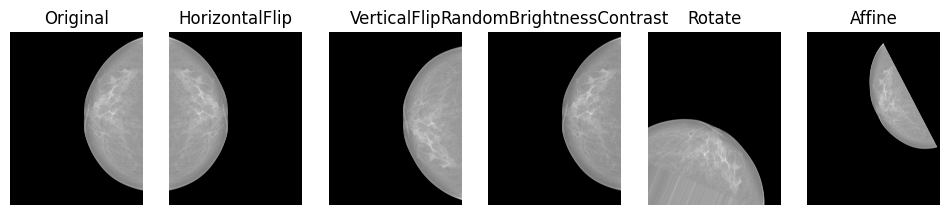

In [49]:
# show original + one example for each augmentation type
import random
import matplotlib.pyplot as plt
import cv2

random_row = df.sample(1).iloc[0]
file_number = str(random_row.get('File Name', '')).strip()
dicom_filename = file_number_to_dicom[file_number]
dicom_path = os.path.join(image_dir, dicom_filename)

ds = pydicom.dcmread(dicom_path)
img = ds.pixel_array.astype(np.float32)
img = cv2.normalize(img, None, 0, 1, cv2.NORM_MINMAX)
if img.ndim == 2:
    img = np.expand_dims(img, axis=-1)  # ensure shape (H, W, 1) for albumentations

augmentations = [
    ("HorizontalFlip", A.HorizontalFlip(p=1.0)),
    ("VerticalFlip", A.VerticalFlip(p=1.0)),
    ("RandomBrightnessContrast", A.RandomBrightnessContrast(brightness_limit=0.15, p=1.0)),
    ("Rotate", A.Rotate(limit=360, p=1.0, border_mode=cv2.BORDER_REPLICATE)),
    ("Affine", A.Affine(scale=(0.6, 1.4), rotate=(-90, 90), p=1.0)),
]

plt.figure(figsize=(12, 3))
plt.subplot(1, len(augmentations) + 1, 1)
plt.imshow(img.squeeze(), cmap='gray')
plt.title('Original')
plt.axis('off')

for i, (name, aug) in enumerate(augmentations):
    # For HueSaturationValue, convert grayscale to 3-channel
    if name == "HueSaturationValue":
        img_rgb = np.repeat(img, 3, axis=-1) if img.shape[-1] == 1 else img
        augmented_img = aug(image=img_rgb)['image']
        # convert back to grayscale for display
        display_img = cv2.cvtColor(augmented_img, cv2.COLOR_RGB2GRAY)
    else:
        # remove channel dimension for albumentations if needed
        img_input = img.squeeze() if img.shape[-1] == 1 else img
        augmented_img = aug(image=img_input)['image']
        display_img = augmented_img
    plt.subplot(1, len(augmentations) + 1, i + 2)
    plt.imshow(display_img, cmap='gray')
    plt.title(name)
    plt.axis('off')

In [50]:
augmented_rows = []
for idx, row in df.iterrows():
    file_number = str(row.get('File Name', '')).strip()
    label = str(row.get('Bi-Rads', '')).strip()
    dicom_filename = file_number_to_dicom[file_number]
    dicom_path = os.path.join(image_dir, dicom_filename)
    ds = pydicom.dcmread(dicom_path)
    img = ds.pixel_array.astype(np.float32)
    img = cv2.normalize(img, None, 0, 1, cv2.NORM_MINMAX)
    orig_png_path = os.path.join(output_dir, f"{file_number}_orig.png")
    cv2.imwrite(orig_png_path, (img * 255).astype(np.uint8))
    augmented_rows.append({'image_path': orig_png_path, 'label': label})
    for i in range(3):
        augmented = augment(image=img)['image']
        aug_png_path = os.path.join(output_dir, f"{file_number}_aug{i}.png")
        cv2.imwrite(aug_png_path, (augmented * 255).astype(np.uint8))
        augmented_rows.append({'image_path': aug_png_path, 'label': label})

aug_df = pd.DataFrame(augmented_rows)
print(f"Total images after augmentation: {len(aug_df)}")

Total images after augmentation: 1640


In [51]:
from tqdm import tqdm

resize_dim = (224, 224)
valid_paths = aug_df['image_path'].apply(lambda x: isinstance(x, str) and os.path.isfile(x))
for img_path in tqdm(aug_df.loc[valid_paths, 'image_path'], desc='Resizing images'):
    img = cv2.imread(img_path)
    if img is not None:
        resized_img = cv2.resize(img, resize_dim, interpolation=cv2.INTER_AREA)
        cv2.imwrite(img_path, resized_img)
    else:
        print(f"Warning: Could not read {img_path}")
print("All images resized to 224x224.")

Resizing images:   0%|          | 0/1640 [00:00<?, ?it/s]

Resizing images: 100%|██████████| 1640/1640 [02:34<00:00, 10.60it/s]

All images resized to 224x224.


In [52]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    aug_df[['image_path', 'label']],
    test_size=0.2,
    random_state=42,
    stratify=aug_df['label']
)

train_df.to_csv('train_split.csv', index=False)
test_df.to_csv('test_split.csv', index=False)

print(f"Train set: {len(train_df)} samples")
print(f"Test set: {len(test_df)} samples")

Train set: 1312 samples
Test set: 328 samples


In [53]:
# accept Bi-Rads labels: 1, 2, 3, 4a, 4b, 4c, 5, 6
valid_labels = ['1', '2', '3', '4a', '4b', '4c', '5', '6']
train_df_clean = train_df[train_df['label'].astype(str).str.lower().isin(valid_labels)].copy()
test_df_clean = test_df[test_df['label'].astype(str).str.lower().isin(valid_labels)].copy()
num_dropped_train = len(train_df) - len(train_df_clean)
num_dropped_test = len(test_df) - len(test_df_clean)
if num_dropped_train > 0 or num_dropped_test > 0:
    print(f"Dropped {num_dropped_train} train and {num_dropped_test} test samples with invalid labels.")
train_df = train_df_clean
test_df = test_df_clean

# Preview image set

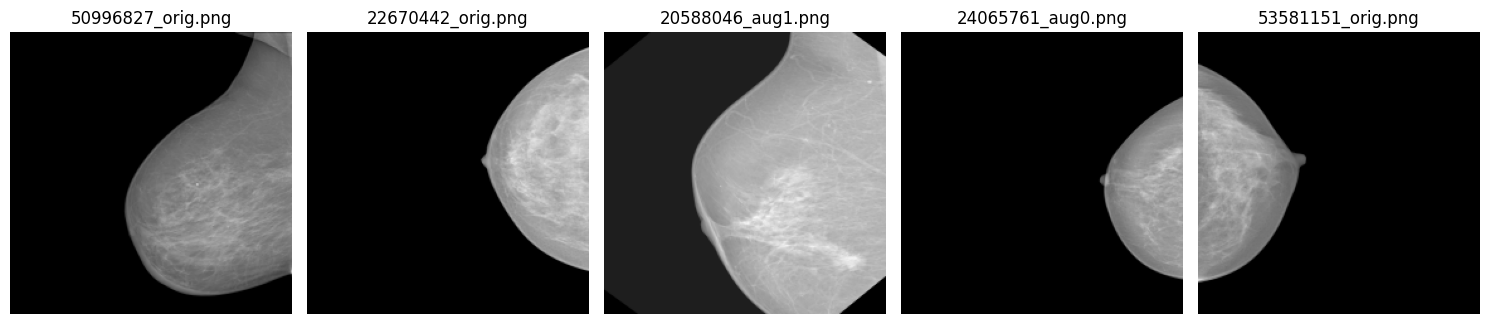

In [54]:
# see random sample of images from the generated CSVs
import random
import matplotlib.pyplot as plt
import pandas as pd
import cv2
import os

# Choose which split to preview: 'train_split.csv' or 'test_split.csv'
csv_to_preview = 'train_split.csv'  # or 'test_split.csv'
df_preview = pd.read_csv(csv_to_preview)

sample_images = random.sample(list(df_preview['image_path']), 5)
plt.figure(figsize=(15, 5))
for i, img_path in enumerate(sample_images):
    img = cv2.imread(img_path)
    if img is not None:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        plt.subplot(1, 5, i + 1)
        plt.imshow(img)
        plt.title(os.path.basename(img_path))
        plt.axis('off')
    else:
        print(f'Warning: Could not read {img_path}')
plt.tight_layout()
plt.show()